# Python Exercise 9 - GenAI Capstone

Rebuild one slice of the Block 5-8 workflow - **load &rarr; summarize &rarr; visualize &rarr; model** - but let **GenAI.mil** write the code. Your job: direct it, and **verify every result** against the &#9989; checks below. If the output doesn't match, the AI (or your prompt) is wrong - fix it before moving on.

**Files:** load `Store 7141 Raw Data (clean).csv`. Column meanings are in the **Data Dictionary** tab of the `.xlsx`.

### Start GenAI.mil with this prompt
> I'm in a Jupyter notebook using pandas, matplotlib, seaborn, and statsmodels. Help me one step at a time, short explanations.
> Data: `Store 7141 Raw Data (clean).csv`, ~50,000 sandwich-shop transactions.
> - Process times (sec): `Bread_CT`, `Cheese_CT`, `Protein_CT`, `Produce_CT`, `Wrap_CT`, `Payment_CT`
> - `Cycle`: total order time (sec)
> - Survey ratings, higher = better: `Conv`, `Wait`, `Value`, `Quality`, `Grade`
> - Categoricals: `Sand`, `Size`, `Shift`, `Month`, `Store`; plus `DateTime`
> Wait for my first request.

## 1. Load & Inspect
> Load `Store 7141 Raw Data (clean).csv` into `store`; show shape, dtypes, and first rows.

&#9989; Shape = **(50847, 32)**.

In [1]:
import pandas as pd

# Load the dataset
store = pd.read_csv('Store 7141 Raw Data (clean).csv')

# Show shape
print("Shape:")
print(store.shape)

# Show dtypes
print("\nData Types:")
print(store.dtypes)

# Show first 5 rows
print("\nFirst 5 rows:")
print(store.head())


Shape:
(50847, 32)

Data Types:
Trans_id            str
Menu_id           int64
Sand_id           int64
Employees         int64
Bread_CT          int64
Cheese_CT         int64
Protein_CT        int64
Produce_CT        int64
Wrap_CT           int64
Payment_CT        int64
Cycle             int64
Labor_Cost          str
Bread_Cost          str
Cheese_Cost         str
Protein_Cost        str
Produce_Cost        str
Wrap_Cost           str
Total_Cost          str
Price               str
Conv              int64
Wait              int64
Value             int64
Quality           int64
Grade             int64
Date              int64
Time            float64
DateTime            str
Month               str
Shift               str
Store             int64
Sand                str
Size                str
dtype: object

First 5 rows:
          Trans_id  Menu_id  Sand_id  Employees  Bread_CT  Cheese_CT  \
0  7141.42739.4326        1        2          1        40         41   
1  7141.42739.4535        6

## 2. Pivot Table
> Pivot the average of each process time by `Shift` (order Morning, Lunch, Mid-Day, Dinner, Evening), rounded to 1 decimal.

&#9989; **Dinner** stands out: `Payment_CT` &asymp; **134s** (vs ~35-41), `Bread_CT` &asymp; **82** (vs ~44).

In [2]:
import pandas as pd

# Load the data if not already in memory
try:
    store
except NameError:
    store = pd.read_csv('Store 7141 Raw Data (clean).csv')

# Define the desired order for the 'Shift' column
shift_order = ['Morning', 'Lunch', 'Mid-Day', 'Dinner', 'Evening']

# Convert 'Shift' to a categorical type with the specified order
store['Shift'] = pd.Categorical(store['Shift'], categories=shift_order, ordered=True)

# Define the process time columns
process_times = ['Bread_CT', 'Cheese_CT', 'Protein_CT', 'Produce_CT', 'Wrap_CT', 'Payment_CT']

# Pivot the data
pivot_table = pd.pivot_table(store, index='Shift', values=process_times, aggfunc='mean')

# Round the results to 1 decimal place and display
print(pivot_table.round(1))



         Bread_CT  Cheese_CT  Payment_CT  Produce_CT  Protein_CT  Wrap_CT
Shift                                                                    
Morning      44.4       35.0        41.0        51.8        13.9     18.3
Lunch        42.2       33.7        35.4        50.5        14.0     16.3
Mid-Day      44.2       34.7        37.8        50.2        14.2     17.5
Dinner       82.3       32.5       134.2        50.7        14.1     15.5
Evening      44.0       35.1        40.5        50.5        14.1     18.6


## 3. Visualize
> Grouped (not stacked) bar chart of that pivot, with title, labels, legend.

&#9989; Dinner's `Payment_CT` bar towers over the rest.

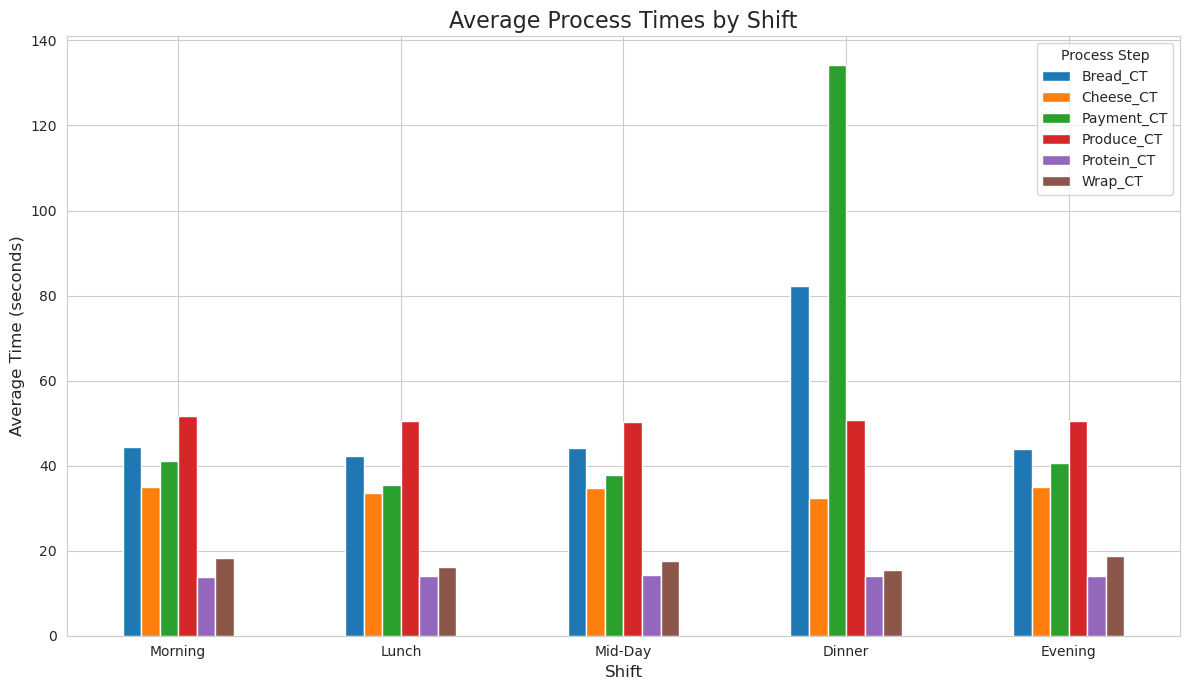

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data if not already in memory
try:
    store
except NameError:
    store = pd.read_csv('Store 7141 Raw Data (clean).csv')

# Define the desired order for the 'Shift' column
shift_order = ['Morning', 'Lunch', 'Mid-Day', 'Dinner', 'Evening']

# Convert 'Shift' to a categorical type with the specified order
store['Shift'] = pd.Categorical(store['Shift'], categories=shift_order, ordered=True)

# Define the process time columns
process_times = ['Bread_CT', 'Cheese_CT', 'Protein_CT', 'Produce_CT', 'Wrap_CT', 'Payment_CT']

# Pivot the data
pivot_table = pd.pivot_table(store, index='Shift', values=process_times, aggfunc='mean')

# Set the plot style
sns.set_style("whitegrid")

# Create the grouped bar chart
ax = pivot_table.plot(kind='bar', figsize=(12, 7))

# Set title and labels
plt.title('Average Process Times by Shift', fontsize=16)
plt.xlabel('Shift', fontsize=12)
plt.ylabel('Average Time (seconds)', fontsize=12)
plt.xticks(rotation=0)

# Add a legend
plt.legend(title='Process Step')

# Display the plot
plt.tight_layout()
plt.show()



> Seaborn scatterplot of `Payment_CT` (x) vs `Wait` (y) on a 1000-row sample.

&#9989; Clear downward trend.

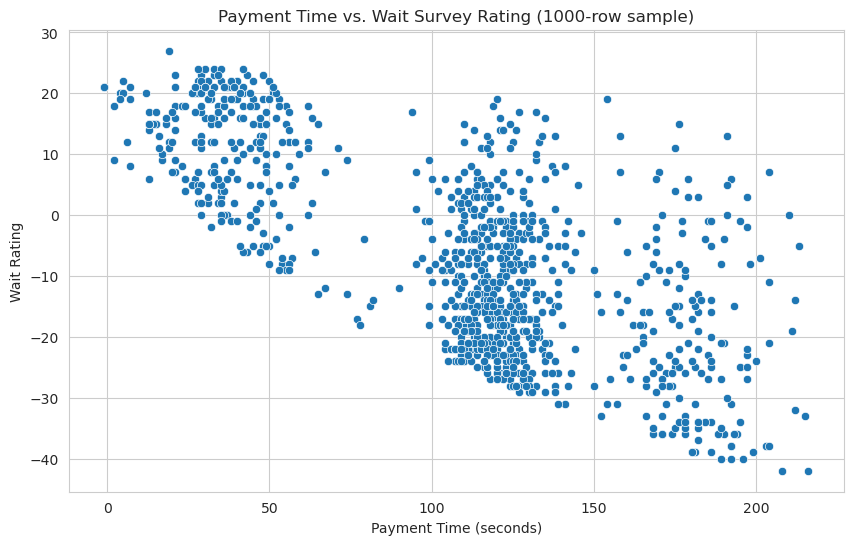

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data if not already in memory
try:
    store
except NameError:
    store = pd.read_csv('Store 7141 Raw Data (clean).csv')

# Take a 1000-row sample
store_sample = store.sample(n=1000, random_state=1)

# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=store_sample, x='Payment_CT', y='Wait')

# Set title and labels
plt.title('Payment Time vs. Wait Survey Rating (1000-row sample)')
plt.xlabel('Payment Time (seconds)')
plt.ylabel('Wait Rating')

# Display the plot
plt.show()



## 4. Model & Compare
> With statsmodels `smf.ols`, regress `Wait` on each process time separately; print slope, R&sup2;, p-value, RMSE; sort into one table by R&sup2;.

&#9989; `Payment_CT` wins (R&sup2; &asymp; **0.49**, slope &asymp; **-0.22**, RMSE &asymp; **11.22**); `Bread_CT` second (R&sup2; &asymp; **0.19**); rest &asymp; 0.

In [8]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# Load the data if not already in memory
try:
    store
except NameError:
    store = pd.read_csv('Store 7141 Raw Data (clean).csv')

# Define the process time columns
process_times = ['Bread_CT', 'Cheese_CT', 'Protein_CT', 'Produce_CT', 'Wrap_CT', 'Payment_CT']
results = []

# Loop through each process time to perform regression
for process in process_times:
    # Create and fit the OLS model
    formula = f'Wait ~ {process}'
    model = smf.ols(formula, data=store).fit()
    
    # Extract the required values
    slope = model.params[process]
    r_squared = model.rsquared
    p_value = model.pvalues[process]
    rmse = np.sqrt(model.mse_resid)
    
    # Append the results to the list
    results.append({
        'Independent Variable': process,
        'Slope': slope,
        'R-squared': r_squared,
        'P-value': p_value,
        'RMSE': rmse
    })

# Create a DataFrame from the results and sort it
results_df = pd.DataFrame(results)
sorted_results = results_df.sort_values(by='R-squared', ascending=False)

# Format the output for better readability
sorted_results['Slope'] = sorted_results['Slope'].map('{:.3f}'.format)
sorted_results['R-squared'] = sorted_results['R-squared'].map('{:.3f}'.format)
sorted_results['P-value'] = sorted_results['P-value'].map('{:.3e}'.format)
sorted_results['RMSE'] = sorted_results['RMSE'].map('{:.2f}'.format)


print(sorted_results.to_string(index=False))


Independent Variable  Slope R-squared   P-value  RMSE
          Payment_CT -0.220     0.486 0.000e+00 11.22
            Bread_CT -0.231     0.186 0.000e+00 14.13
           Cheese_CT  0.023     0.000 9.268e-04 15.66
          Protein_CT -0.021     0.000 6.532e-02 15.66
          Produce_CT -0.007     0.000 1.242e-01 15.66
             Wrap_CT  0.004     0.000 7.981e-01 15.66


> (Bonus) Using the `Payment_CT` model, solve for the `Payment_CT` that predicts `Wait` = 12.

&#9989; &asymp; **22 seconds**.

In [9]:
import pandas as pd
import statsmodels.formula.api as smf

# Load the data if not already in memory
try:
    store
except NameError:
    store = pd.read_csv('Store 7141 Raw Data (clean).csv')

# Create and fit the OLS model for Payment_CT
model = smf.ols('Wait ~ Payment_CT', data=store).fit()

# Extract the intercept and slope
intercept = model.params['Intercept']
slope = model.params['Payment_CT']

# Target Wait value
target_wait = 12

# Solve for Payment_CT
# Equation: Wait = intercept + slope * Payment_CT
# Rearranged: Payment_CT = (Wait - intercept) / slope
predicted_payment_ct = (target_wait - intercept) / slope

print(f"The model's intercept is: {intercept:.2f}")
print(f"The model's slope is: {slope:.2f}")
print(f"\nTo predict a 'Wait' rating of {target_wait}, the 'Payment_CT' would need to be approximately {predicted_payment_ct:.1f} seconds.")



The model's intercept is: 16.85
The model's slope is: -0.22

To predict a 'Wait' rating of 12, the 'Payment_CT' would need to be approximately 22.1 seconds.


## Reflection
*(short answers)*
- Where did GenAI get it right first try, and where did you have to correct it?
- How did building this by hand in Blocks 5-8 help you catch its mistakes?
- When would you trust AI-written analysis code - and when not?